In [1]:
####Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, optimize
from copulas.bivariate import Clayton, Gumbel, Frank
from copulas.multivariate import GaussianMultivariate

****Introduction****

In [ ]:
####We fit copulas on the residual data, which (actual log returns - fitted log returns). 
####The log returns are not independent and Auto Correlation is present in them, which is clear form ACF and PACF plots. 
####Thus, the exlainable variability is contained by ARMA model and the random shock is being modelled by copulas. 
####Thus, copulas can be modelled in order to trace the interdependency in the residuals portion of our data. 


****EDA and Marginal Fitting****

In [148]:
data_crypto = pd.read_csv(r'/Users/kanishka/Documents/IAQS/Semester 4/SRM4/PAML_Project/residuals_crypto.csv').reset_index(drop=True)
data_tech = pd.read_csv(r'/Users/kanishka/Documents/IAQS/Semester 4/SRM4/PAML_Project/residuals_tech.csv').reset_index(drop=True)

In [149]:
####Summary Stats crypto residuals
data_crypto.describe()
####The mean of residuals is very small

,crypto_resid,crytpo_losses
count,1.499000e+03,1.499000e+03
mean,3.898108e-07,-3.898108e-07
std,5.801810e-04,5.801810e-04
min,-2.059417e-03,-2.305700e-03
25%,-3.643240e-04,-3.879665e-04
50%,-1.851286e-05,1.851286e-05
75%,3.879665e-04,3.643240e-04
max,2.305700e-03,2.059417e-03


In [160]:
data_tech.describe()
####The mean of residuals is very small.

,Tech_resid,tech_losses
count,1499.000000,1499.000000
mean,0.000001,-0.000001
std,0.000288,0.000288
min,-0.007999,-0.000823
25%,-0.000132,-0.000141
50%,0.000013,-0.000013
75%,0.000141,0.000132
max,0.000823,0.007999


In [161]:
####Correlation Analysis 
pearson_r = data_tech['Tech_resid'].corr(data_crypto['crypto_resid'],method='pearson')
kendal_tau = data_tech['Tech_resid'].corr(data_crypto['crypto_resid'],method='kendall')
spearman_r = data_tech['Tech_resid'].corr(data_crypto['crypto_resid'],method='spearman')
print(f"Pearson rho : {pearson_r.round(5)}, Spearman rho : {spearman_r.round(5)}, Kendal Tau : {kendal_tau.round(5)}")

Pearson rho : 0.4047, Spearman rho : 0.52716, Kendal Tau : 0.37725


In [162]:
####Now, spearman > pearson suggests non linear dependence, though gap is minimal. 
####Also, Kendal Tau is lower. 
###Thus, pearson is underestimating true dependence to some extent as it captures only linear dependence. 
###Hence, we are considering concordance measures such as kendal and spearman. 
####THUs, copulas are needed here. 

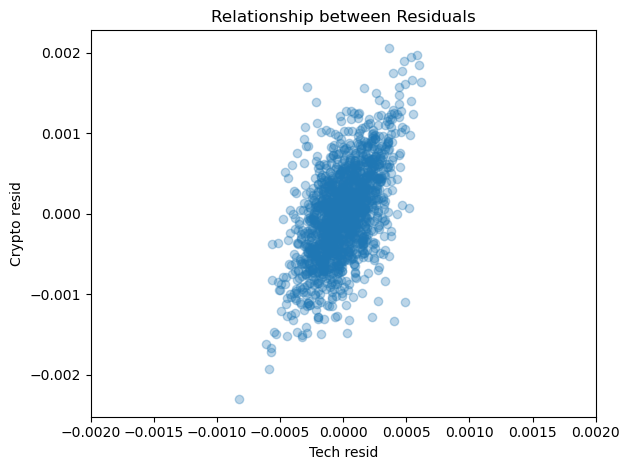

In [163]:
####Interdepnedency ANalysis

#Losses Scatter
plt.scatter(data_tech['tech_losses'],data_crypto['crytpo_losses'],alpha=.3)
plt.xlabel('Tech resid')
plt.ylabel('Crypto resid')
plt.title('Relationship between Residuals')
plt.xlim(-0.002, 0.002)

plt.tight_layout()
plt.show()


In [164]:
data_tech.head()

,Tech_resid,tech_losses
0,-0.007999,0.007999
1,0.000003,-0.000003
2,0.000336,-0.000336
3,0.000081,-0.000081
4,0.000340,-0.000340


In [165]:
####Trying to fit the Marginal distributions 

####Ideally, tech and crypto losses seem to follow normal, the QQ Plot strongly suggests that, also, the symmetric nature of histogram for both Tech and Crypto 

####However, Lets evaluate the fit on the following other Distributions as well. 
####Student-t
####Laplace
####Logistic
####Skew Normal 
####


####Preparing data 
tech_data_resid = data_tech['Tech_resid'].values
crypto_data_resid = data_crypto['crypto_resid'].values

####prop_dist_params will return (shape1, shape2, shape3,....,location,scale) poarameters. 
#Now we perform Kolmogorov-Simranof Test. (KS Test). It tests the fit of the dist
###If pval < .05, we have sufficient evidence to reject H0. If pval>.05, we have insufficient evidence 
##to reject H0. H0: Data follows the distribution. 
###H1: Data does not follow the specific distribution. 
###This tst if for continous distroibution
###The output contains test statiostic, pvalue, which are important

###Tech
#Normal
tech_norm_params = stats.norm.fit(tech_data_resid)
tech_norm_ks = stats.kstest(tech_data_resid,'norm',tech_norm_params)

#Skew Normal
tech_skew_norm_params = stats.skewnorm.fit(tech_data_resid)
tech_skew_ks = stats.kstest(tech_data_resid,'skewnorm',tech_skew_norm_params)

# Laplace
tech_laplace_params = stats.laplace.fit(tech_data_resid)
tech_laplace_ks = stats.kstest(tech_data_resid, 'laplace', tech_laplace_params)

# Logistic
tech_logistic_params = stats.logistic.fit(tech_data_resid)
tech_logistic_ks = stats.kstest(tech_data_resid, 'logistic', tech_logistic_params)

# Student-t
tech_t_params = stats.t.fit(tech_data_resid)
tech_t_ks = stats.kstest(tech_data_resid, 't', tech_t_params)


tech_kstest_summary = pd.DataFrame(
    {
        'Skewnorm' : [tech_skew_ks[0].round(5), tech_skew_ks[1].round(5)],
        'Laplace'  : [tech_laplace_ks[0].round(5),tech_laplace_ks[1].round(5)],
        'Logistic' : [tech_logistic_ks[0].round(5),tech_logistic_ks[1].round(5)],
        'Student-t': [tech_t_ks[0].round(5),tech_t_ks[1].round(5)],
        'Normal' : [tech_norm_ks[0].round(5), tech_norm_ks[1].round(5)]
    },
    index=['TS','pvalue']
)
print('Tech KS Test Summary')
print(tech_kstest_summary)

#Crypto
crypto_norm_params = stats.norm.fit(crypto_data_resid)
crypto_norm_ks = stats.kstest(crypto_data_resid,'norm',crypto_norm_params)

#Skew Normal
crypto_skew_norm_params = stats.skewnorm.fit(crypto_data_resid)
crypto_skew_ks = stats.kstest(crypto_data_resid,'skewnorm',crypto_skew_norm_params)

# Laplace
crypto_laplace_params = stats.laplace.fit(crypto_data_resid)
crypto_laplace_ks = stats.kstest(crypto_data_resid, 'laplace', crypto_laplace_params)

# Logistic
crypto_logistic_params = stats.logistic.fit(crypto_data_resid)
crypto_logistic_ks = stats.kstest(crypto_data_resid, 'logistic', crypto_logistic_params)

# Student-t
crypto_t_params = stats.t.fit(crypto_data_resid)
crypto_t_ks = stats.kstest(crypto_data_resid, 't', crypto_t_params)

crypto_kstest_summary = pd.DataFrame(
    {
        'Skewnorm' : [crypto_skew_ks[0].round(5), crypto_skew_ks[1].round(5)],
        'Laplace'  : [crypto_laplace_ks[0].round(5),crypto_laplace_ks[1].round(5)],
        'Logistic' : [crypto_logistic_ks[0].round(5),crypto_logistic_ks[1].round(5)],
        'Student-t': [crypto_t_ks[0].round(5),crypto_t_ks[1].round(5)],
        'Normal' : [crypto_norm_ks[0].round(5), crypto_norm_ks[1].round(5)]
    },
    index=['TS','pvalue']
)
print('Crypto KS Test Summary')
print(crypto_kstest_summary)


Tech KS Test Summary
        Skewnorm  Laplace  Logistic  Student-t   Normal
TS       0.08595  0.04757   0.02332    0.03690  0.09362
pvalue   0.00000  0.00219   0.38310    0.03291  0.00000
Crypto KS Test Summary
        Skewnorm  Laplace  Logistic  Student-t   Normal
TS       0.01924  0.05647   0.02268    0.03830  0.02031
pvalue   0.62883  0.00014   0.41740    0.02395  0.55925


In [175]:
####Thus, Logistic is the best fit for Tech and Skewnorm is th best fit for Crypto as it has highest p-value and lowest KS Statistic and thus, 
#####TS lies far away from rejection region. Thus, most insufficient evidence to reject H0 will be if we choose logistic for both. 

####Now, we compute ,marginal cdfs. 

best_tech_dist = stats.logistic(*tech_logistic_params)
best_crypto_dist = stats.skewnorm(*crypto_logistic_params)

###* helps us to mention an ordered array in the syntax 

u = np.clip(best_tech_dist.cdf(tech_data_resid),1e-8,1-(1e-8))
v = np.clip(best_crypto_dist.cdf(crypto_data_resid),1e-8,1-(1e-8))


(np.float64(7.5719855019527565e-06), np.float64(0.00011834680805378133))

****Copula Fitting****

In [167]:
copula_df = pd.DataFrame(
    {
        'u' : u,
        'v' : v
    }
)

###Fitting Copulas
###Gumbel Copula
gumbel_cop = Gumbel()
gumbel_cop.fit(copula_df.values)

##Clayton Copula
clayton_cop = Clayton()
clayton_cop.fit(copula_df.values)

##Frank Copula
frank_cop = Frank()
frank_cop.fit(copula_df.values)

##Guassian Copula
gaus_cop = GaussianMultivariate()
gaus_cop.fit(copula_df)

###The parameter values

gumbel_theta = gumbel_cop.theta
parameter = pd.DataFrame({
    'gumbel theta' : gumbel_cop.theta,
    'clayton theta' : clayton_cop.theta,
    'frank theta' : frank_cop.theta,
    'gaussian rho' : gaus_cop.correlation.iloc[0,1]
},index=['Parameter Est'])


parameter

/opt/anaconda3/lib/python3.13/site-packages/copulas/bivariate/base.py:163: RuntimeWarning: Data does not appear to be uniform.
  warnings.warn('Data does not appear to be uniform.', category=RuntimeWarning)
/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:795: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:800: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))


,gumbel theta,clayton theta,frank theta,gaussian rho
Parameter Est,1.605779,1.211558,3.855617,0.557428


****Metrics****

In [168]:
##Computing Log Likelihood
gumbel_ll = gumbel_cop.log_probability_density(copula_df.values).sum()
clayton_ll = clayton_cop.log_probability_density(copula_df.values).sum()
frank_ll = frank_cop.log_probability_density(copula_df.values).sum()
gaus_ll = gaus_cop.log_probability_density(copula_df.values).sum()

In [169]:
####Computing AIC
gumbel_aic = 2*(1-gumbel_ll)
clayton_aic = 2*(1-clayton_ll)
frank_aic = 2*(1-frank_ll)
gaus_aic = 2*(1-gaus_ll)

####Computing BIC
ln_n = np.log(len(copula_df))
gumbel_bic = 1*ln_n-2*gumbel_ll
clayton_bic = 1*ln_n-2*clayton_ll
frank_bic = 1*ln_n-2*frank_ll
gaus_bic = 1*ln_n-2*gaus_ll

##Computing Tau Gap 
emp_tau = stats.kendalltau(u,v)[0]

###Getting the statistic 

gumbel_gap = abs(gumbel_cop.tau-emp_tau)
clayton_gap = abs(clayton_cop.tau-emp_tau)
frank_gap = abs(frank_cop.tau-emp_tau)
gaus_gap = abs((2/np.pi)*np.arcsin(gaus_cop.correlation.iloc[0,1])-emp_tau)


metrics = pd.DataFrame({
    'log likelihoiod':[gumbel_ll,clayton_ll,frank_ll,gaus_ll],
    'AIC':[gumbel_aic,clayton_aic,frank_aic,gaus_aic],
    'BIC' : [gumbel_bic,clayton_bic,frank_bic,gaus_bic],
    'tau_gap' : [gumbel_gap,clayton_gap,frank_gap,gaus_gap]
},index=['Gumbel','Clayton','Frank','Gaussian'])

metrics


,log likelihoiod,AIC,BIC,tau_gap
Gumbel,-75.571240,153.142480,158.455033,0.000000
Clayton,-163.728476,329.456951,334.769505,0.000000
Frank,-46.789681,95.579362,100.891916,0.000000
Gaussian,-3906.285457,7814.570915,7819.883468,0.000826


In [170]:
####AIC, BIC and Tau_gap, lower the better, Log Likelihood, higher the better
####Thus, Frank is a clear winner. From the interdependency plot itself, we can judge that there is minimal tail dependence

****Tail Dependence****

In [171]:
# Tail Dependence Coefficients
gumbel_theta = gumbel_cop.theta
clayton_theta = clayton_cop.theta
frank_theta = frank_cop.theta
gaus_rho = gaus_cop.correlation.iloc[0,1]

tail_dep = pd.DataFrame({
    'Lower Tail': [0, 2**(-1/clayton_theta), 0, 0],
    'Upper Tail': [2 - 2**(1/gumbel_theta), 0, 0, 0]
}, index=['Gumbel', 'Clayton', 'Frank', 'Gaussian'])

print(tail_dep)

###Our choosen copula was frank. From the plot only, we could understand that their is no upper and lower tail dependence, which is again 
###validated by theorotical value of coef of upper and lower tail dependence. 

          Lower Tail  Upper Tail
Gumbel      0.000000    0.460192
Clayton     0.564332    0.000000
Frank       0.000000    0.000000
Gaussian    0.000000    0.000000


****Joint Probability****

In [176]:
####Var for Crypto 0.0014816466928773313
### VAR for tech 0.0004908623235885751

tech_var = 0.0004908623235885751
crypto_var = 0.0014816466928773313

tech_u = best_tech_dist.cdf(tech_var)
crypto_v = best_crypto_dist.cdf(crypto_var)

joint_prob = pd.DataFrame({
    'u' : [tech_u],
    'v' : [crypto_v]
})

print(f"The joint probability that both assets experience a loss exceeding their 95 percenitle VaR simultaneosly  : {1-tech_u-crypto_v+frank_cop.cumulative_distribution(joint_prob.values)}")


The joint probability that both assets experience a loss exceeding their 95 percenitle VaR simultaneosly  : [0.01439844]
